# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [152]:
# !pip install opendatasets --upgrade --quiet
# import opendatasets as od
# od.download('https://www.kaggle.com/datasets/blastchar/telco-customer-churn')

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [155]:
df.shape

(7043, 21)

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [157]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space):
- y (target variable): churn
- Probability distribution of y: Bernoulli distribution
- Natural loss function: binary cross-entropy loss
- Hypothesis class:
- Assumption 1:
- Assumption 2:
- Assumption 3:
- Sources of uncertainty:

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [158]:
from matplotlib import pyplot as plt
import seaborn as sns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<Axes: xlabel='MonthlyCharges', ylabel='Count'>

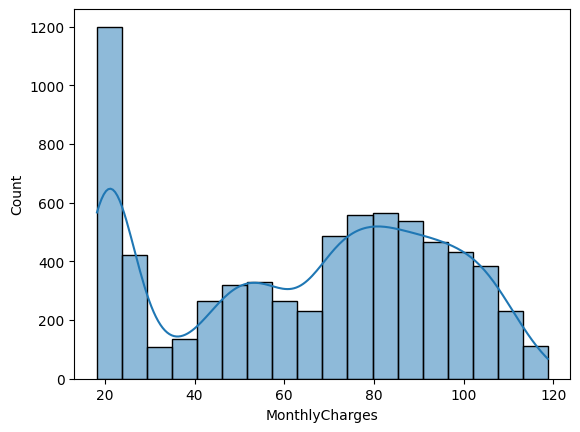

In [159]:
sns.histplot(df['MonthlyCharges'], kde=True)

<Axes: xlabel='tenure', ylabel='Count'>

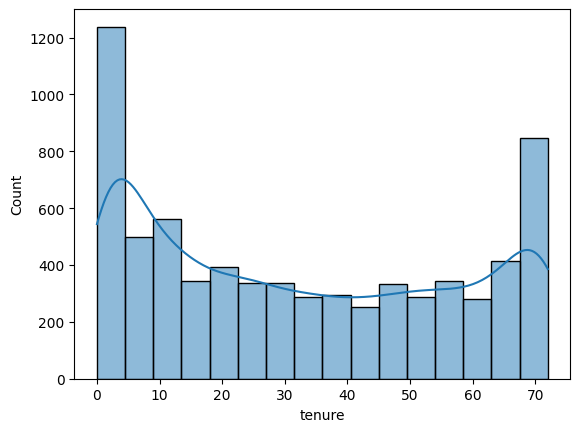

In [160]:
sns.histplot(df['tenure'],kde=True)

In [161]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # replacing whitespace with NaN, so that it shows missing data


In [162]:
df['MonthlyCharges']= pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['tenure']= pd.to_numeric(df['tenure'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<Axes: xlabel='TotalCharges', ylabel='Count'>

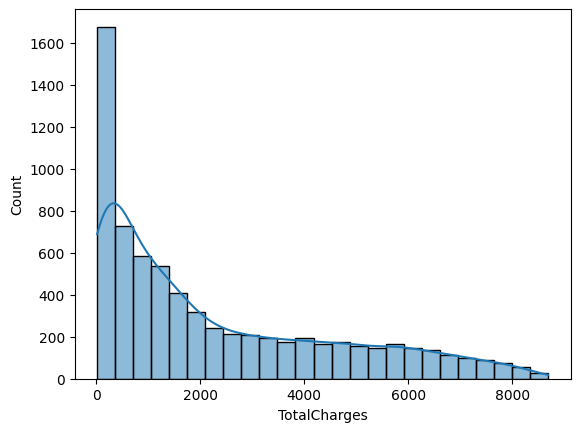

In [163]:
sns.histplot(df['TotalCharges'],kde=True)

In [164]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0}).astype('bool')
df['Churn'].head()

,Churn
0,False
1,False
2,True
3,False
4,True


In [165]:
df['Churn'].value_counts()

,count
Churn,
False,5174
True,1869


---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [166]:
from sklearn.dummy import DummyClassifier
baseline=DummyClassifier(strategy='most_frequent')

In [167]:
#fitting nb
baseline.fit(None,df['Churn'])


DummyClassifier(strategy='most_frequent')

In [168]:
baseline.predict(['True','True','True','True','True','True']) # always gives the majority probability answer

array([False, False, False, False, False, False])

In [169]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
False,0.73463
True,0.26537


---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [170]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [171]:
df.drop('customerID',axis=1,inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,False
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,False
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,True
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,False
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,True


In [172]:
df_encoded=pd.get_dummies(df, drop_first=True) #drop_first=True, because we don't need two columns for the same binary feature
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,False,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,False,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [173]:
#df_encoded.info() #see how all our non numerical data are boolean now

Step 1: Temporarily store the 30% remainder in x_remainder and y_remainder

In [174]:
x_train,x_remainder,y_train,y_remainder=train_test_split(df_encoded.drop('Churn',axis=1),df_encoded['Churn'],stratify=df_encoded['Churn'],test_size=0.30,random_state=42)
#x-train,x_rem,y_train,y_rem=train_test_split(X:features ,y:target, stratify=y, test_size=0.30, random_state=42)


Split that X_remainder into the final X_val and X_test equally, that is 15% of the total data each

In [175]:
x_val,x_test,y_val,y_test=train_test_split(x_remainder,y_remainder,stratify=y_remainder,test_size=0.5,random_state=42)


Now lets scale(Normalize) our numerical data


In [176]:
# 1. Define numeric columns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 2. Fill missing values in TotalCharges with the training median to avoid errors, logistic regression doesn't allow Nan missing values
train_median = x_train['TotalCharges'].median()
x_train['TotalCharges'] = x_train['TotalCharges'].fillna(train_median)
x_val['TotalCharges'] = x_val['TotalCharges'].fillna(train_median)
x_test['TotalCharges'] = x_test['TotalCharges'].fillna(train_median)

# 3. Initialize the Scaler
scaler = StandardScaler()

# 4. Fit ONLY on the training data
scaler.fit(x_train[numeric_cols])

# 5. Create scaled versions of our datasets
x_train_scaled = x_train.copy()
x_val_scaled = x_val.copy()
x_test_scaled = x_test.copy()

x_train_scaled[numeric_cols] = scaler.transform(x_train[numeric_cols])
x_val_scaled[numeric_cols] = scaler.transform(x_val[numeric_cols])
x_test_scaled[numeric_cols] = scaler.transform(x_test[numeric_cols])

print("Numeric features scaled successfully.")
display(x_train_scaled[numeric_cols].head())

Numeric features scaled successfully.


,tenure,MonthlyCharges,TotalCharges
5557,-1.114728,0.504286,-0.837871
2270,-1.195884,0.724189,-0.909151
6930,-1.195884,0.337292,-0.910985
2257,1.117066,0.515860,1.110142
898,-0.830682,1.122660,-0.516301


In [177]:
x_train_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5557,0,-1.114728,0.504286,-0.837871,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
2270,1,-1.195884,0.724189,-0.909151,False,False,False,True,False,False,...,False,True,False,False,False,False,True,False,True,False
6930,0,-1.195884,0.337292,-0.910985,False,True,False,True,False,True,...,False,False,False,False,False,False,True,True,False,False
2257,0,1.117066,0.515860,1.110142,False,False,False,True,False,True,...,False,True,False,True,True,False,False,True,False,False
898,0,-0.830682,1.122660,-0.516301,False,False,False,True,False,False,...,False,True,False,True,False,False,True,False,False,False


Training a Naive regression model


In [178]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Evaluate the baseline on the validation set
y_val_baseline = baseline.predict(x_val_scaled)

baseline_acc = accuracy_score(y_val, y_val_baseline)
baseline_prec = precision_score(y_val, y_val_baseline, zero_division=0)
baseline_recall = recall_score(y_val, y_val_baseline)
baseline_f1 = f1_score(y_val, y_val_baseline)

print("--- Naive Baseline (Predict Most Frequent) ---")
print(f"Validation Accuracy:  {baseline_acc:.4f}")
print(f"Validation Precision: {baseline_prec:.4f}")
print(f"Validation Recall:    {baseline_recall:.4f}")
print(f"Validation F1-Score:  {baseline_f1:.4f}")

--- Naive Baseline (Predict Most Frequent) ---
Validation Accuracy:  0.7348
Validation Precision: 0.0000
Validation Recall:    0.0000
Validation F1-Score:  0.0000


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [180]:
import time
result_metrics=[]

logistic regresssion

In [181]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

# Initialize the model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Fit on scaled training data
start_time_lr=time.time()
log_reg.fit(x_train_scaled, y_train)
end_time_lr=time.time()
# Quick check on validation set
y_val_pred = log_reg.predict(x_val_scaled)

# Calculate metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

#predict_proba()
y_proba=log_reg.predict_proba(x_val_scaled)[:,1] #sliced because predict_proba
#returns two column, nochurn(0) then churn(1), so we slice off the nochurn
roc_auc= roc_auc_score(y_val, y_proba)
pr_auc= average_precision_score(y_val, y_proba)
ll= log_loss(y_val, y_proba)

#append into list metrics
result_metrics.append({'model':'Logistic Regression',
                       'accuracy':val_accuracy,
                       'precision':val_precision,
                       'recall':val_recall,
                       'f1':val_f1,
                       'roc-auc':roc_auc,
                       'pr-auc':pr_auc,
                       'log-loss':ll})

#print(result_metrics)

print("--- Logistic Regression Performance ---")
print(f"Validation Accuracy:  {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")
print(f"Validation F1-Score:  {val_f1:.4f}")
print(f"Time taken to train model: {end_time_lr-start_time_lr:.4f} sec")

--- Logistic Regression Performance ---
Validation Accuracy:  0.8068
Validation Precision: 0.6484
Validation Recall:    0.5929
Validation F1-Score:  0.6194
Time taken to train model: 0.0396 sec


ridge classifier

In [182]:
from sklearn.linear_model import RidgeClassifier
import numpy as np

#Initialize the model
ridge_clf=RidgeClassifier()

#Fit on scaled training data
start_time_ridge=time.time()
ridge_clf.fit(x_train_scaled,y_train)
end_time_ridge=time.time()

#predict
y_val_pred=ridge_clf.predict(x_val_scaled)

#metrics
val_accuracy=accuracy_score(y_val,y_val_pred)
val_precision=precision_score(y_val,y_val_pred)
val_recall=recall_score(y_val,y_val_pred)
val_f1=f1_score(y_val,y_val_pred)

# calculate prob for roc-auc,pr-auc,logloss
y_proba=ridge_clf.decision_function(x_val_scaled)
roc_auc=roc_auc_score(y_val,y_proba)
pr_auc=average_precision_score(y_val,y_proba)

ll=np.nan #na for ridge

#append into list metrics

result_metrics.append({'model':'Ridge Classifier',
                       'accuracy':val_accuracy,
                       'precision':val_precision,
                       'recall':val_recall,
                       'f1':val_f1,
                       'roc-auc':roc_auc,
                       'pr-auc':pr_auc,
                       'log-loss':ll})

#print(result_metrics)

print("--- Ridge Classifier Performance ---")
print(f"Validation Accuracy:  {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")
print(f"Validation F1-Score:  {val_f1:.4f}")

print(f"Time taken to train model: {end_time_ridge-start_time_ridge:.4f} sec")


--- Ridge Classifier Performance ---
Validation Accuracy:  0.8030
Validation Precision: 0.6538
Validation Recall:    0.5464
Validation F1-Score:  0.5953
Time taken to train model: 0.0852 sec


SGD Classifier

In [183]:
from sklearn.linear_model import SGDClassifier

#initialize model
sgd_clf = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)

#fit model
start_time_sgd=time.time()
sgd_clf.fit(x_train_scaled, y_train) #fit model
end_time_sgd=time.time()

#predict
y_val_pred = sgd_clf.predict(x_val_scaled)

#metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
# proba for roc-auc,pr-auc,ll
y_proba = sgd_clf.predict_proba(x_val_scaled)[:, 1]
roc_auc = roc_auc_score(y_val, y_proba)
pr_auc = average_precision_score(y_val, y_proba)
ll = log_loss(y_val, y_proba)

result_metrics.append({'model':'SGD Classifier',
                       'accuracy':val_accuracy,
                       'precision':val_precision,
                       'recall':val_recall,
                       'f1':val_f1,
                       'roc-auc':roc_auc,
                       'pr-auc':pr_auc,
                       'log-loss':ll})

#print(result_metrics)

print("--- SGD Classifier Performance ---")
print(f"Validation Accuracy:  {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")
print(f"Validation F1-Score:  {val_f1:.4f}")
print(f"Time taken to train model: {end_time_sgd-start_time_sgd:.4f} sec")


--- SGD Classifier Performance ---
Validation Accuracy:  0.7973
Validation Precision: 0.6204
Validation Recall:    0.6071
Validation F1-Score:  0.6137
Time taken to train model: 0.0920 sec


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [184]:
#print(result_metrics)
comparison_table=pd.DataFrame(result_metrics).sort_values('pr-auc',ascending=False)
comparison_table

,model,accuracy,precision,recall,f1,roc-auc,pr-auc,log-loss
0,Logistic Regression,0.806818,0.648438,0.592857,0.619403,0.845317,0.630788,0.418785
2,SGD Classifier,0.797348,0.620438,0.607143,0.613718,0.843646,0.625091,0.421625
1,Ridge Classifier,0.803030,0.653846,0.546429,0.595331,0.837875,0.624359,NaN


---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


In [185]:
from sklearn.metrics import roc_curve, precision_recall_curve

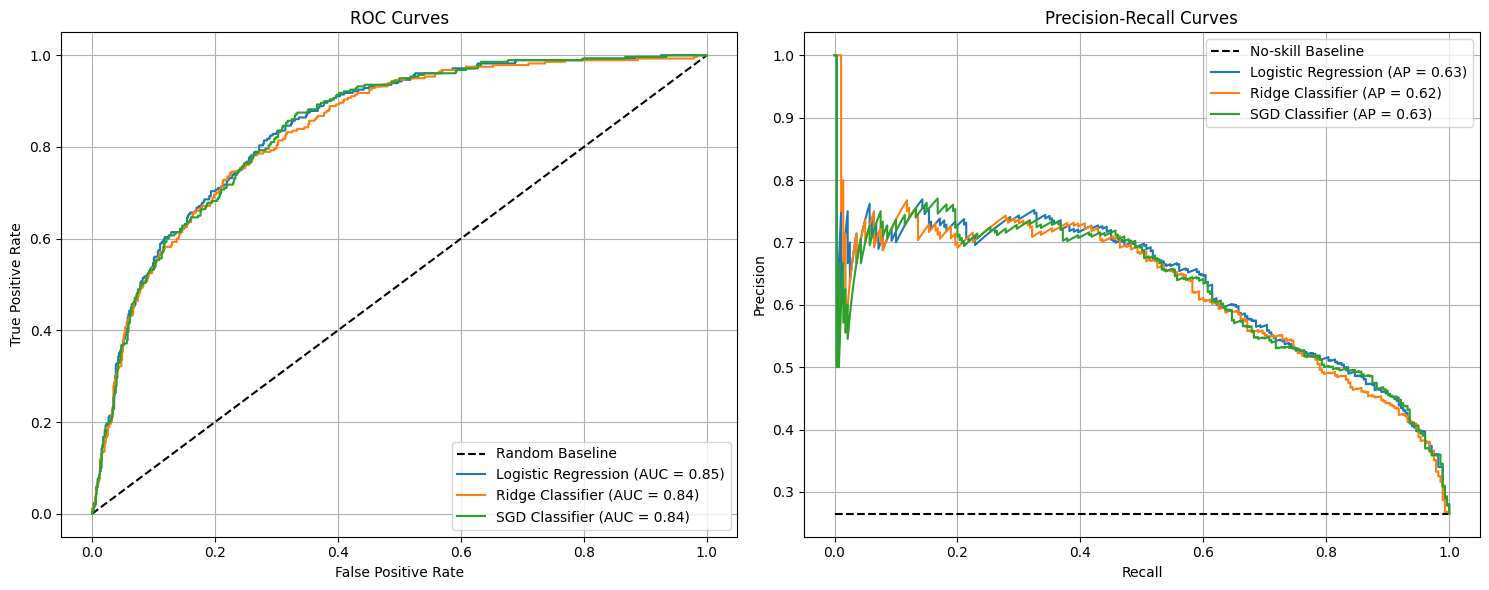

In [186]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
ax1.plot([0, 1], [0, 1], 'k--', label='Random Baseline')

# PR Curve
ax2.plot([0, 1], [0.265, 0.265], 'k--', label='No-skill Baseline') # baseline for PR-AUC is prevalence of positive class

# Iterate through each model in result_metrics to plot curves
for model_metrics in result_metrics:
    model_name = model_metrics['model']

    if model_name == 'Logistic Regression':
        y_scores = log_reg.predict_proba(x_val_scaled)[:, 1]
    elif model_name == 'Ridge Classifier':
        y_scores = ridge_clf.decision_function(x_val_scaled)
    elif model_name == 'SGD Classifier':
        y_scores = sgd_clf.predict_proba(x_val_scaled)[:, 1]
    else:
        continue # Skip if model is not recognized

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_scores) #false positive rate vs false negative rate for roc curve
    ax1.plot(fpr, tpr, label=f'{model_name} (AUC = {model_metrics["roc-auc"]:.2f})')

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_val, y_scores)
    ax2.plot(recall, precision, label=f'{model_name} (AP = {model_metrics["pr-auc"]:.2f})')


ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend()
ax1.grid(True)

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [187]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Get predicted probabilities for Logistic Regression
y_val_probs = log_reg.predict_proba(x_val_scaled)[:, 1]

# 2. Sort probabilities and pick the 200th highest value as the threshold
sorted_probs = np.sort(y_val_probs)[::-1]
top_200_threshold = sorted_probs[199] #the 200th highest probability in the sorted list becomes the new classification threshold.

# 3. Apply the threshold
y_pred_200 = (y_val_probs >= top_200_threshold).astype(int)
y_pred_default = (y_val_probs >= 0.5).astype(int) #generates binary predictions using the standard default threshold of 0.5.

# 4. Compare Metrics
metrics_comp = {
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Top 200 Budget (Thresh=' + f'{top_200_threshold:.3f})': [
        precision_score(y_val, y_pred_200),
        recall_score(y_val, y_pred_200),
        f1_score(y_val, y_pred_200)
    ],
    'Default (Thresh=0.500)': [
        precision_score(y_val, y_pred_default),
        recall_score(y_val, y_pred_default),
        f1_score(y_val, y_pred_default)
    ]
}

display(pd.DataFrame(metrics_comp))

,Metric,Top 200 Budget (Thresh=0.561),Default (Thresh=0.500)
0,Precision,0.695000,0.648438
1,Recall,0.496429,0.592857
2,F1-Score,0.579167,0.619403


---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


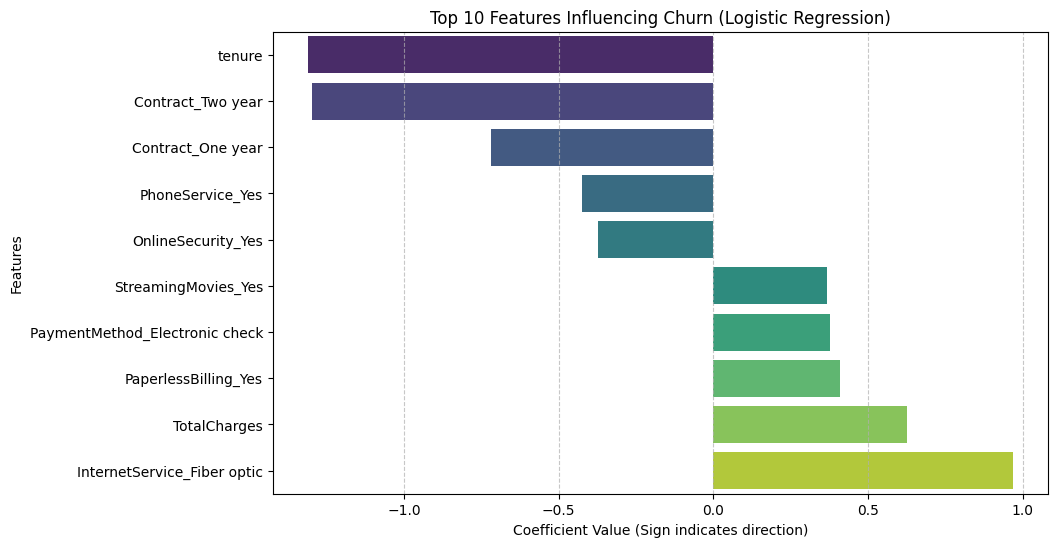

Interpretation:
- Positive coefficients (e.g., Fiber optic) increase the likelihood of churn.
- Negative coefficients (e.g., Tenure, Two-year contract) decrease the likelihood of churn.


In [188]:
feature_names = x_train.columns #get all features(cols) from train dataset
# Extract coefficients for Logistic Regression
coefs = pd.Series(log_reg.coef_[0], index=feature_names) #These coefficients indicate the strength and direction of a feature's influence on churn

# Get top 10 features by absolute magnitude
top_10_features = coefs.abs().nlargest(10).index # finds the 10 largest ones, and gets their corresponding feature names.
top_10_coefs = coefs[top_10_features].sort_values() #It then selects the actual coefficient values for these top 10 features and sorts them in ascending order

# Plot
plt.figure(figsize=(10, 6))
# Fixed FutureWarning by assigning y to hue
sns.barplot(x=top_10_coefs.values, y=top_10_coefs.index, hue=top_10_coefs.index, palette='viridis', legend=False)
plt.title('Top 10 Features Influencing Churn (Logistic Regression)')
plt.xlabel('Coefficient Value (Sign indicates direction)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Interpretation:")
print("- Positive coefficients (e.g., Fiber optic) increase the likelihood of churn.")
print("- Negative coefficients (e.g., Tenure, Two-year contract) decrease the likelihood of churn.")

---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [189]:
# 1. Initialize SGD with log_loss to match Logistic Regression
sgd_log = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)

# 2. Time the training for comparison
start_lr = time.time()
log_reg.fit(x_train_scaled, y_train)
end_lr = time.time()

start_sgd = time.time()
sgd_log.fit(x_train_scaled, y_train)
end_sgd = time.time()

# 3. Compare Coefficients
coef_agreement = np.allclose(log_reg.coef_, sgd_log.coef_, atol=0.2)

print(f"Logistic Regression (Full-batch) Training Time: {end_lr - start_lr:.4f}s")
print(f"SGD Classifier (Stochastic) Training Time:   {end_sgd - start_sgd:.4f}s")
print("-" * 30)
print(f"Are coefficients approximately the same (atol=0.2)? {coef_agreement}")

# 4. Compare Predictions overlap
y_pred_lr = log_reg.predict(x_val_scaled)
y_pred_sgd = sgd_log.predict(x_val_scaled)
overlap = (y_pred_lr == y_pred_sgd).mean()
print(f"Prediction overlap between models: {overlap:.2%}")

Logistic Regression (Full-batch) Training Time: 0.1076s
SGD Classifier (Stochastic) Training Time:   0.1285s
------------------------------
Are coefficients approximately the same (atol=0.2)? False
Prediction overlap between models: 97.16%


In [190]:
best_cla_model=log_reg

logistic regression because it has the hightest precison, roc-auc, pr-auc,f1 and the precison can get even higher to 69% if we target the top 200


---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


In [191]:
df_encoded['CLV']=df_encoded['tenure']*df_encoded['MonthlyCharges']
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,CLV
0,0,1,29.85,29.85,False,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,29.85
1,0,34,56.95,1889.50,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,True,1936.30
2,0,2,53.85,108.15,True,True,False,False,True,False,...,False,False,False,False,False,True,False,False,True,107.70
3,0,45,42.30,1840.75,False,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,1903.50
4,0,2,70.70,151.65,True,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,141.40


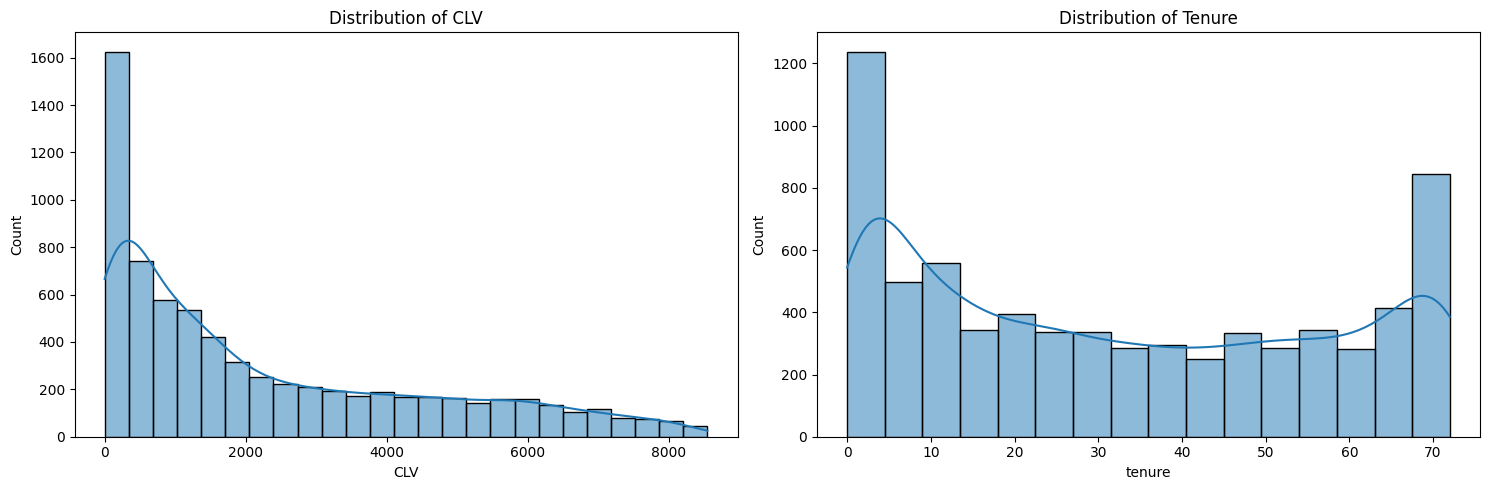

In [192]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))

sns.histplot(df_encoded['CLV'],kde=True, ax=ax1)
ax1.set_title('Distribution of CLV')

sns.histplot(df_encoded['tenure'],kde=True, ax=ax2)
ax2.set_title('Distribution of Tenure')



plt.tight_layout()
plt.show()

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [193]:
col=['tenure','MonthlyCharges','TotalCharges','CLV']
df_encoded[col].head() # TotalCharges looks like CSV with some hidden charges

,tenure,MonthlyCharges,TotalCharges,CLV
0,1,29.85,29.85,29.85
1,34,56.95,1889.50,1936.30
2,2,53.85,108.15,107.70
3,45,42.30,1840.75,1903.50
4,2,70.70,151.65,141.40


For tenure as target variable

In [194]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
result_metrics_reg=[]

# get correct rows of target
y_train_reg = x_train['tenure']
y_val_reg = x_val['tenure']


#get features, remove tenure
x_train_reg = x_train_scaled.drop(columns=['tenure'])
x_val_reg = x_val_scaled.drop(columns=['tenure'])


#model fitting
lin_reg = LinearRegression().fit(x_train_reg, y_train_reg)

lasso_reg = Lasso(alpha=0.1).fit(x_train_reg, y_train_reg)

ridge_reg = Ridge(alpha=1.0).fit(x_train_reg, y_train_reg)

elastic_reg=ElasticNet(alpha=0.1).fit(x_train_reg, y_train_reg)

#predict
# lin_reg.predict(x_val_reg)
# lasso_reg.predict(x_val_reg)
# ridge_reg.predict(x_val_reg)

#metrics
result_metrics_reg.append({'model': 'Linear Regression',
                           'mae': round(mean_absolute_error(y_val_reg, lin_reg.predict(x_val_reg)),3),
                           'rmse': round(np.sqrt(mean_squared_error(y_val_reg, lin_reg.predict(x_val_reg))),3),
                           'r2': round(r2_score(y_val_reg, lin_reg.predict(x_val_reg)),3)})

result_metrics_reg.append({'model': 'Lasso Regression',
                           'mae': round(mean_absolute_error(y_val_reg, lasso_reg.predict(x_val_reg)),3),
                           'rmse': round(np.sqrt(mean_squared_error(y_val_reg, lasso_reg.predict(x_val_reg))),3),
                           'r2': round(r2_score(y_val_reg, lasso_reg.predict(x_val_reg)),3)})

result_metrics_reg.append({'model': 'Ridge Regression',
                           'mae': round(mean_absolute_error(y_val_reg, ridge_reg.predict(x_val_reg)),3),
                           'rmse': round(np.sqrt(mean_squared_error(y_val_reg, ridge_reg.predict(x_val_reg))),3),
                           'r2': round(r2_score(y_val_reg, ridge_reg.predict(x_val_reg)),3)})

result_metrics_reg.append({'model': 'Elastic Regression',
                           'mae': round(mean_absolute_error(y_val_reg, elastic_reg.predict(x_val_reg)),3),
                           'rmse': round(np.sqrt(mean_squared_error(y_val_reg, elastic_reg.predict(x_val_reg))),3),
                           'r2': round(r2_score(y_val_reg, elastic_reg.predict(x_val_reg)),3)})


show_res= pd.DataFrame(result_metrics_reg)
show_res.head()

,model,mae,rmse,r2
0,Linear Regression,6.763,8.899,0.865
1,Lasso Regression,6.692,8.935,0.864
2,Ridge Regression,6.762,8.900,0.865
3,Elastic Regression,6.649,9.137,0.858


In [195]:
best_reg_model=lin_reg

In [196]:
#linear regresson seems to be our best model with r2, which means our model accounts for  86.52% the story
# it gives r2=1, mae=0 and rsme=0 when i don't drop the ['tenure'] col from feature but wouln't that be data leakage?


---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


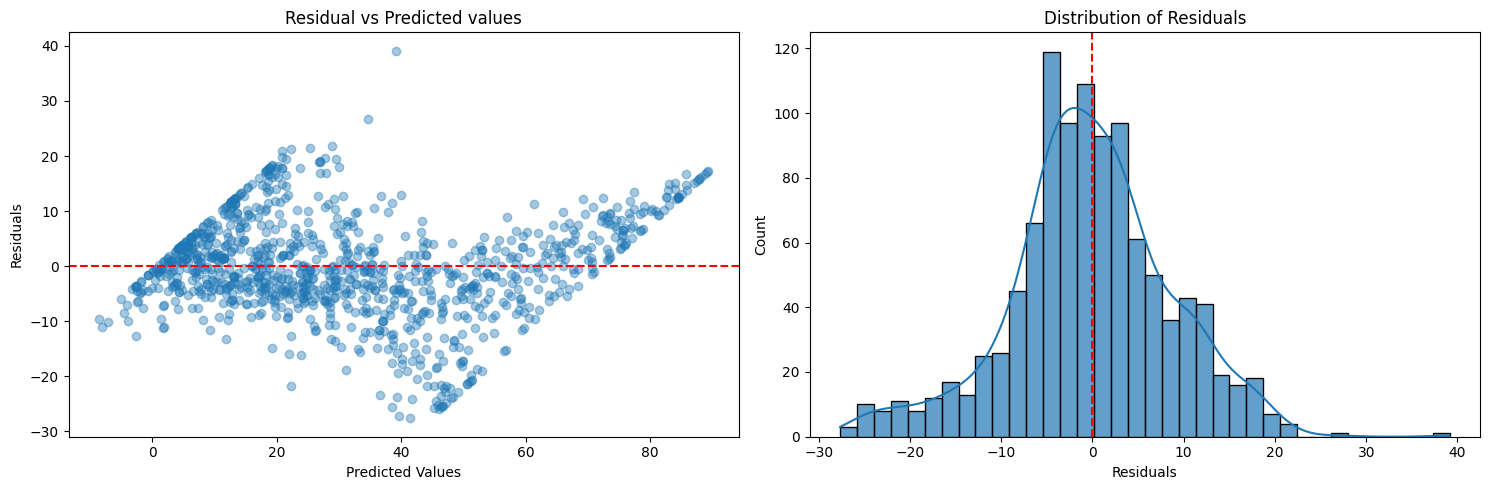

In [197]:
y_pred = lin_reg.predict(x_val_reg)
residuals = y_pred - y_val_reg

fig,(ax1,ax2) =plt.subplots(1,2,figsize=(15,5))

ax1.scatter(y_pred, residuals, alpha=0.4)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Predicted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residual vs Predicted values')

sns.histplot(residuals,kde=True, ax=ax2, alpha=0.7)
ax2.axvline(0, color='red', linestyle='--')
ax2.set_title('Distribution of Residuals')
ax2.set_xlabel('Residuals')

plt.tight_layout()
plt.show()

---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


In [198]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

#list of alpha values to go through
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
alpha_results=[]

for a in alphas:
  #fitting models
  ridge_reg=Ridge(alpha=a).fit(x_train_reg, y_train_reg)
  lasso_reg=Lasso(alpha=a).fit(x_train_reg, y_train_reg)
  elastic_reg=ElasticNet(alpha=a).fit(x_train_reg, y_train_reg)





  alpha_results.append({
                        'alpha': a,
                        #'Ridge': ridge_reg.coef_,
                        'Lasso': lasso_reg.coef_,
                        #'Elastic': elastic_reg.coef_,
                        })



coef_matrix = pd.DataFrame(alpha_results)
coef_matrix.head()

#how many features survive at each alpha?




/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.578e+05, tolerance: 2.994e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.559e+05, tolerance: 2.994e+02
  model = cd_fast.enet_coordinate_descent(


,alpha,Lasso
0,0.001,"[0.8678616297277334, -6.832731523008863, 23.51..."
1,0.010,"[0.8264716483178626, -9.27555952325115, 23.482..."
2,0.100,"[0.3465864988458534, -9.547214352626677, 23.53..."
3,1.000,"[0.0, -8.123004532289077, 23.955757835418794, ..."
4,10.000,"[-0.0, -0.0, 10.450690629809408, -0.0, 0.0, 0...."


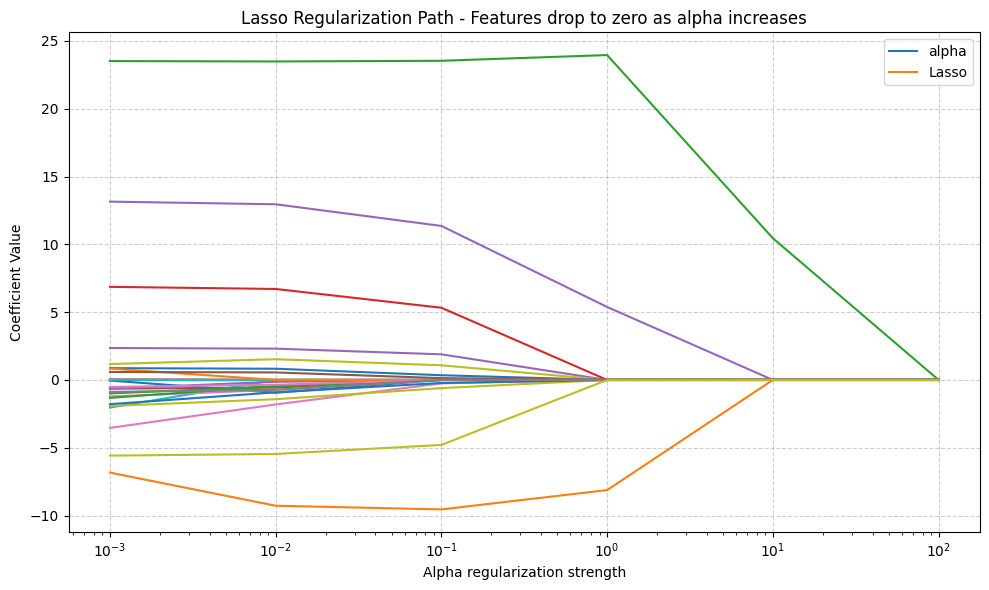

In [199]:
import matplotlib.pyplot as plt
import numpy as np

# Extract coefficients for plotting from Dataframe
lasso_paths = np.array([res['Lasso'] for res in alpha_results])

# Plot Lasso
plt.figure(figsize=(10, 6))
plt.plot(alphas, lasso_paths)
plt.xscale('log')
plt.title('Lasso Regularization Path - Features drop to zero as alpha increases')
plt.xlabel('Alpha regularization strength')
plt.ylabel('Coefficient Value')
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(coef_matrix.columns)
plt.tight_layout()
plt.show()

You'll notice that as alpha increases (moving right along the x-axis), the absolute values of many coefficients tend to decrease. This is the regularization at work, pushing the model to be simpler.

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [200]:
df_encoded['CLV'].describe()

,CLV
count,7043.000000
mean,2279.581350
std,2264.729447
min,0.000000
25%,394.000000
50%,1393.600000
75%,3786.100000
max,8550.000000


In [201]:
# x_val['MonthlyCharges']

In [202]:
predicted_tenure=lin_reg.predict(x_val_reg)
predicted_tenure=np.maximum(predicted_tenure,0)
clv=x_val['MonthlyCharges']*predicted_tenure

# print(len(predicted_tenure))
# print(predicted_tenure)

print(f"Mean CLV: ${clv.mean():.2f}" )
print(f"Median CLV: ${ clv.median():.2f}")
print(f"Max CLV: ${clv.max():.2f}")




Mean CLV: $2223.22
Median CLV: $1121.58
Max CLV: $10272.66


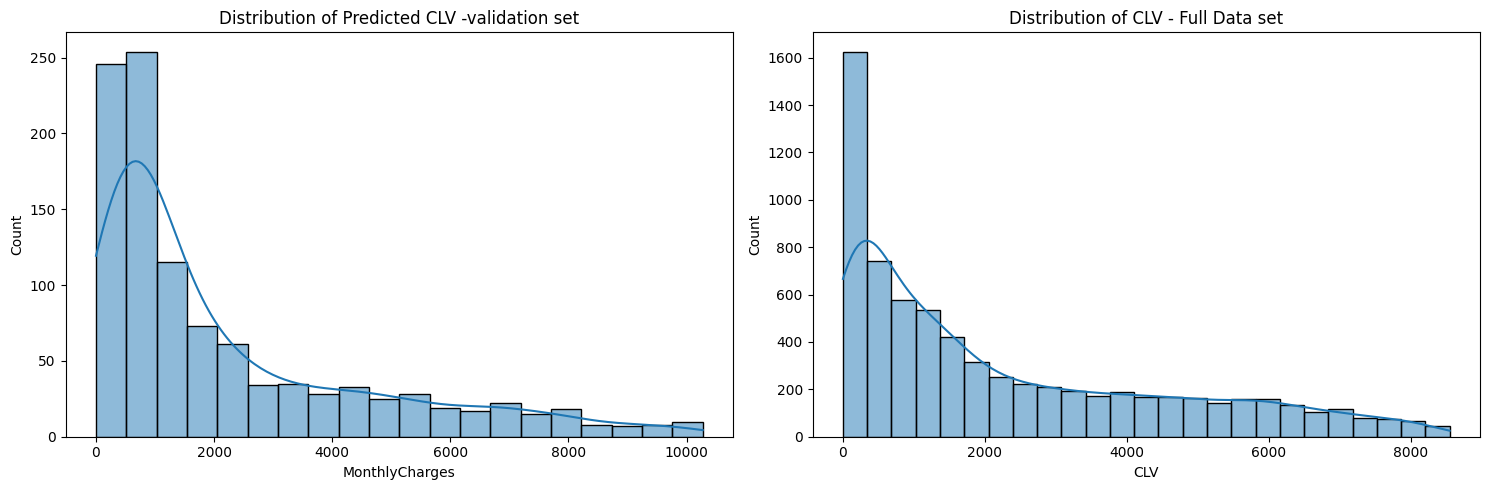

In [203]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,5))

sns.histplot(clv,kde=True, ax=ax1)
ax1.set_title('Distribution of Predicted CLV -validation set')

sns.histplot(df_encoded['CLV'],kde=True, ax=ax2)
ax2.set_title('Distribution of CLV - Full Data set')

plt.tight_layout()
plt.show()

In [204]:
print(f'lin reg: {round(r2_score(y_val_reg, best_reg_model.predict(x_val_reg)),3)}' )
lasso_reg = Lasso(alpha=10).fit(x_train_reg, y_train_reg)
print(f'lasso reg: {round(r2_score(y_val_reg, lasso_reg.predict(x_val_reg)),3)}')

lin reg: 0.865
lasso reg: 0.509


for alpha value of (a=0.1) it gives r2 of 0.86 and at (a=10) lasso drops r2 to 0.51,which is because lasso drops many features as seen from the Lasso Regularization Path plot above at (a=10)

---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [205]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_score=cross_val_score(best_cla_model, x_train_scaled, y_train, cv=skf, scoring='roc_auc')
print(cv_score)

[0.83345752 0.85686352 0.82856058 0.8464953  0.85598456]


In [206]:
print(f'Best Classification model:{best_cla_model}')
print(f'mean: {cv_score.mean():.3f}')
print(f'std: {cv_score.std():.3f}')

Best Classification model:LogisticRegression(max_iter=1000, random_state=42)
mean: 0.844
std: 0.012


---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


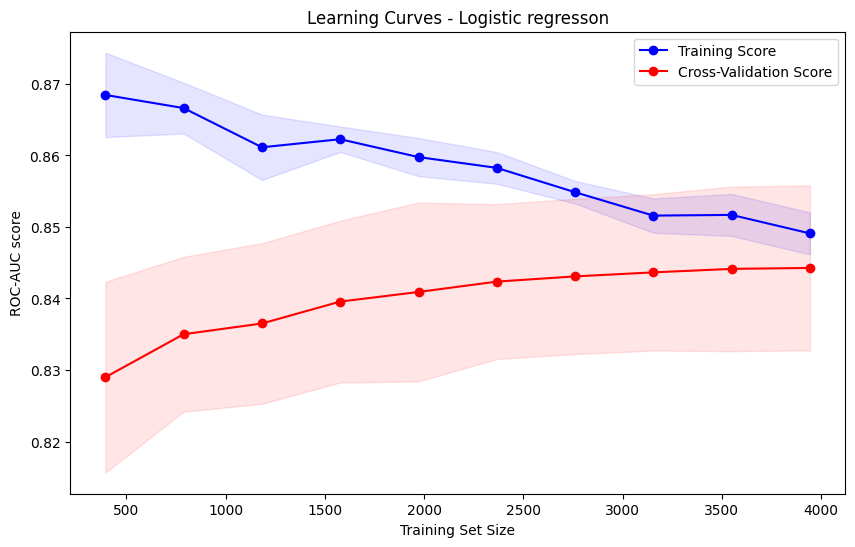

In [207]:
from sklearn.model_selection import learning_curve

#calculate learning curve
train_sizes, train_scores, val_scores = learning_curve(
    best_cla_model, x_train_scaled, y_train,
    cv=skf, scoring='roc_auc',
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1)

#calculate mean and sd
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

#plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean,'o-', label='Training Score', color='blue')
plt.plot(train_sizes, val_mean,'o-', label='Cross-Validation Score', color='red')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')

plt.title('Learning Curves - Logistic regresson')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC score')
plt.legend()

plt.show()

In [208]:
print(f'final train score: {train_mean[-1]:.3f}')
print(f'final val score: {val_mean[-1]:.3f}')
print(f'difference: {train_mean[-1]-val_mean[-1]:.3f}')

final train score: 0.849
final val score: 0.844
difference: 0.005


---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [209]:
x_val.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6906,0,25,18.70,383.65,False,True,True,True,False,False,...,True,False,True,False,False,True,True,False,False,True
6015,0,3,74.55,233.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
2142,0,21,64.85,1336.80,False,False,True,True,False,False,...,False,False,False,True,True,False,False,False,False,True
2080,1,72,84.10,5981.65,True,True,False,True,False,True,...,False,True,False,True,False,True,True,True,False,False
6488,0,1,69.50,69.50,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [210]:
# Step 1: Record baseline metrics
from sklearn.metrics import roc_auc_score,average_precision_score

y_proba=best_cla_model.predict_proba(x_val_scaled)[:,1] #sliced because predict_proba
#returns two column, nochurn(0) then churn(1), so we slice off the nochurn

baseline_auc=roc_auc_score(y_val,y_proba)
baseline_ap=average_precision_score(y_val,y_proba)
print('Baseline metrics -------------')
print(f'baseline AUC: {baseline_auc:.3f}')
print(f'baseline AP: {baseline_ap:.3f}')

Baseline metrics -------------
baseline AUC: 0.845
baseline AP: 0.631


In [211]:
# Step 2: Create and add the leakage feature
leak=x_val['tenure']*y_val+np.random.normal(0,0.1,len(x_val))
x_val['leakage']=leak

In [212]:
x_val.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,leakage
6906,0,25,18.70,383.65,False,True,True,True,False,False,...,False,True,False,False,True,True,False,False,True,-0.013317
6015,0,3,74.55,233.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,0.119164
2142,0,21,64.85,1336.80,False,False,True,True,False,False,...,False,False,True,True,False,False,False,False,True,0.138174
2080,1,72,84.10,5981.65,True,True,False,True,False,True,...,True,False,True,False,True,True,True,False,False,-0.114168
6488,0,1,69.50,69.50,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1.037559


In [213]:
# Step 3: Retrain on the same split and record metrics
clf_leak=best_cla_model.fit(x_val,y_val)
y_proba_leak=clf_leak.predict_proba(x_val)[:,1]

leak_auc=roc_auc_score(y_val,y_proba_leak)
leak_ap=average_precision_score(y_val,y_proba_leak)
print('Leakage feature metrics -------------')
print(f'AUC: {leak_auc} | AUC increase: {leak_auc-baseline_auc:.3f}')
print(f'AP :{leak_ap}  |  AP increase: {leak_ap-baseline_ap:.3f}')

Leakage feature metrics -------------
AUC: 1.0 | AUC increase: 0.155
AP :1.0  |  AP increase: 0.369


In [214]:
import pandas as pd

# Step 4: Show feature importances — does the leakage feature dominate?
# clf_leak was fitted on x_val, which now includes 'leakage'
coef_leak = pd.Series(clf_leak.coef_[0], index=x_val.columns).abs().sort_values(ascending=False)

print('Feature importances -------------')
print(coef_leak.head(5).round(4))

Feature importances -------------
leakage                 4.2939
PaperlessBilling_Yes    0.3975
tenure                  0.3605
MultipleLines_Yes       0.3343
PhoneService_Yes        0.3100
dtype: float64


In [215]:
x_val.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,leakage
6906,0,25,18.70,383.65,False,True,True,True,False,False,...,False,True,False,False,True,True,False,False,True,-0.013317
6015,0,3,74.55,233.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,0.119164
2142,0,21,64.85,1336.80,False,False,True,True,False,False,...,False,False,True,True,False,False,False,False,True,0.138174
2080,1,72,84.10,5981.65,True,True,False,True,False,True,...,True,False,True,False,True,True,True,False,False,-0.114168
6488,0,1,69.50,69.50,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,1.037559


In [216]:
# Step 5: Remove leakage feature, retrain, confirm metrics return to baseline

best_cla_model.fit(x_train_scaled, y_train)

proba_clean = best_cla_model.predict_proba(x_val_scaled)[:,1]

# Calculate baseline metrics with the fresh model
new_baseline_auc = roc_auc_score(y_val, proba_clean)
new_baseline_ap = average_precision_score(y_val, proba_clean)

print('Metrics after removing leakage and retraining (should match original baseline):')
print(f'New Baseline AUC: {new_baseline_auc:.3f}')
print(f'New Baseline AP: {new_baseline_ap:.3f}')

# The original 'baseline_auc' and 'baseline_ap' variables still hold these values from cell cLG4GvmNLqGv
print('\nOriginal Baseline Metrics (for comparison):')
print(f'Original AUC: {baseline_auc:.3f}')
print(f'Original AP: {baseline_ap:.3f}')

# Revert x_val by dropping the 'leakage' column if it still exists (for subsequent steps)
if 'leakage' in x_val.columns:
    x_val.drop(columns=['leakage'], inplace=True)

x_val.head()

Metrics after removing leakage and retraining (should match original baseline):
New Baseline AUC: 0.845
New Baseline AP: 0.631

Original Baseline Metrics (for comparison):
Original AUC: 0.845
Original AP: 0.631


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6906,0,25,18.70,383.65,False,True,True,True,False,False,...,True,False,True,False,False,True,True,False,False,True
6015,0,3,74.55,233.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
2142,0,21,64.85,1336.80,False,False,True,True,False,False,...,False,False,False,True,True,False,False,False,False,True
2080,1,72,84.10,5981.65,True,True,False,True,False,True,...,False,True,False,True,False,True,True,True,False,False
6488,0,1,69.50,69.50,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [217]:
# Step 6: Summary table — Before / With Leakage / After Removal
import pandas as pd

summary_data = {
    'Scenario': ['Before Leakage', 'With Leakage', 'After Leakage Removal'],
    'AUC': [baseline_auc, leak_auc, new_baseline_auc],
    'AP': [baseline_ap, leak_ap, new_baseline_ap]
}

summary_df = pd.DataFrame(summary_data)
print('Summary of Leakage Impact:')
print(summary_df.round(3))

Summary of Leakage Impact:
                Scenario    AUC     AP
0         Before Leakage  0.845  0.631
1           With Leakage  1.000  1.000
2  After Leakage Removal  0.845  0.631


---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [218]:
x_test.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1639,1,17,45.05,770.60,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3776,0,43,56.35,2391.15,True,True,False,True,False,False,...,False,True,False,False,True,False,True,False,False,True
805,0,72,76.80,5468.45,False,True,True,True,False,True,...,False,True,False,True,False,True,True,False,False,False
2923,0,54,89.80,4667.00,True,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,True
5392,0,63,39.35,2395.05,True,True,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False


for best classification model

In [219]:
test_proba=best_cla_model.predict_proba(x_test_scaled)[:,1]
test_auc=roc_auc_score(y_test,test_proba)
test_ap=average_precision_score(y_test,test_proba)
print('Classification Test set metrics -------------')
print(f'Threshold used: {top_200_threshold:.3f} top-200')
print(f'ROC-AUC: {test_auc:.3f}')
print(f'PR-AUC: {test_ap:.3f}')
print(f'Accuracy: {round(accuracy_score(y_test,best_cla_model.predict(x_test_scaled)),3)}')
print(f'Precision: {round(precision_score(y_test,best_cla_model.predict(x_test_scaled)),3)}')
print(f'Recall: {round(recall_score(y_test,best_cla_model.predict(x_test_scaled)),3)}')
print(f'F1: {round(f1_score(y_test,best_cla_model.predict(x_test_scaled)),3)}')
print(f'log loss: {round(log_loss(y_test,best_cla_model.predict_proba(x_test_scaled)),3)}')


Classification Test set metrics -------------
Threshold used: 0.561 top-200
ROC-AUC: 0.845
PR-AUC: 0.659
Accuracy: 0.81
Precision: 0.687
Recall: 0.523
F1: 0.594
log loss: 0.417


In [220]:
#print(result_metrics)

for best regression model


In [221]:
x_test_reg=x_test_scaled.drop(columns=['tenure'],inplace=True)
y_test_reg=x_test['tenure']

In [222]:
print(result_metrics_reg)


[{'model': 'Linear Regression', 'mae': 6.763, 'rmse': np.float64(8.899), 'r2': 0.865}, {'model': 'Lasso Regression', 'mae': 6.692, 'rmse': np.float64(8.935), 'r2': 0.864}, {'model': 'Ridge Regression', 'mae': 6.762, 'rmse': np.float64(8.9), 'r2': 0.865}, {'model': 'Elastic Regression', 'mae': 6.649, 'rmse': np.float64(9.137), 'r2': 0.858}]


In [223]:

# test_pred=best_reg_model.predict(x_test_scaled)
print('Regression Test Set Metrics -------------')
print(f'r2score: {round(r2_score(y_test_reg, best_reg_model.predict(x_test_scaled)),3)}')
print(f'RMSE: {round(np.sqrt(mean_squared_error(y_test_reg, best_reg_model.predict(x_test_scaled))),3)}')
print(f'MAE: { round(mean_absolute_error(y_test_reg, best_reg_model.predict(x_test_scaled)),3)}')

Regression Test Set Metrics -------------
r2score: 0.852
RMSE: 9.416
MAE: 7.082


---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | **Logistic regression**
| **Chosen Regression Model** | **Linear regression**
| **Key Classification Metrics (test set)** | Precision: &nbsp; Recall: &nbsp; F1: &nbsp;  PR-AUC: |
| **Key Regression Metrics (test set)** | MAE &nbsp; RMSE: &nbsp; R²: |
| **Deployment Threshold** |  0.561
| **Threshold Justification** | Top 200 custmoers due to budget constraint
| **Known Limitations** | Class imbalance (27% churn)
| **What Could Go Wrong in Production** | customer who receive retention offer become biased re-training sample
| **Monitoring Plan** | Track precision @200 weekly after deployment
| **Are Linear Models Sufficient?** | Yes
| **Evidence for Your Decision** | has a high enough ROC-AUC and R2

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
